# Predicting Irrigation Need: LightGBM 
Lucas Calaff
04/20/26

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, classification_report
from lightgbm import LGBMClassifier

## 1. Data importing and Preprocessing 

In [5]:
Train_df = pd.read_csv("train.csv")
Train_df = Train_df.drop(columns=['id'])
Train_df.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [6]:
X = Train_df.drop(['Irrigation_Need'], axis=1)
y = Train_df['Irrigation_Need']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_val_encoded = pd.get_dummies(X_val, drop_first=True)

x_val_encoded = X_val_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

## 3. LightGBM Base Model

In [7]:
# building a lightgbm model

lgbm_model = LGBMClassifier(random_state=42)
lgbm_model.fit(X_train_encoded, y_train_encoded)
y_val_pred = lgbm_model.predict(x_val_encoded)
print(classification_report(y_val_encoded, y_val_pred, target_names=le.classes_))
print("F1 Score:", f1_score(y_val_encoded, y_val_pred, average='weighted'))

C:\Users\ldcal\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\ldcal\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\ldcal\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\ldcal\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006110 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2713
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 35
[LightGBM] [Info] Start training from score -3.403581
[LightGBM] [Info] Start training from score -0.531609
[LightGBM] [Info] Start training from score -0.969989
              precision    recall  f1-score   support

        High       0.94      0.91      0.93      4249
         Low       0.99      0.99      0.99     73737
      Medium       0.98      0.97      0.98     48014

    accuracy                           0.98    126000
   macro avg       0.97      0.96      0.96    126000
weighted avg       0.98      0.98      0.98    126000

F1 Score: 0.9833087635206164


LightGBM was by far the fastest model ive tried so far with it only taking 4 seconds to fit, whist other models can take upwards of 20 mins. 

## 4. Tuning the N_Estimators parameter 

In [10]:
# param grid for N_Estimators
param_grid = {
    'n_estimators': [5,10, 25, 50, 100]
}

grid_search = GridSearchCV(estimator= lgbm_model, param_grid=param_grid, cv=5, scoring='f1_weighted')
grid_search.fit(X_train_encoded, y_train_encoded)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004785 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2713
[LightGBM] [Info] Number of data points in the train set: 403200, number of used features: 35
[LightGBM] [Info] Start training from score -3.403581
[LightGBM] [Info] Start training from score -0.531609
[LightGBM] [Info] Start training from score -0.969989
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003651 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2711
[LightGBM] [Info] Number of data points in the train set: 403200, number of used features: 35
[LightGBM] [Info] Start training from score -3.403581
[LightGBM] [Info] Start training from score -0.531609
[LightGBM] [Info] Star

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMClassifie...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_estimators': [5, 10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and can

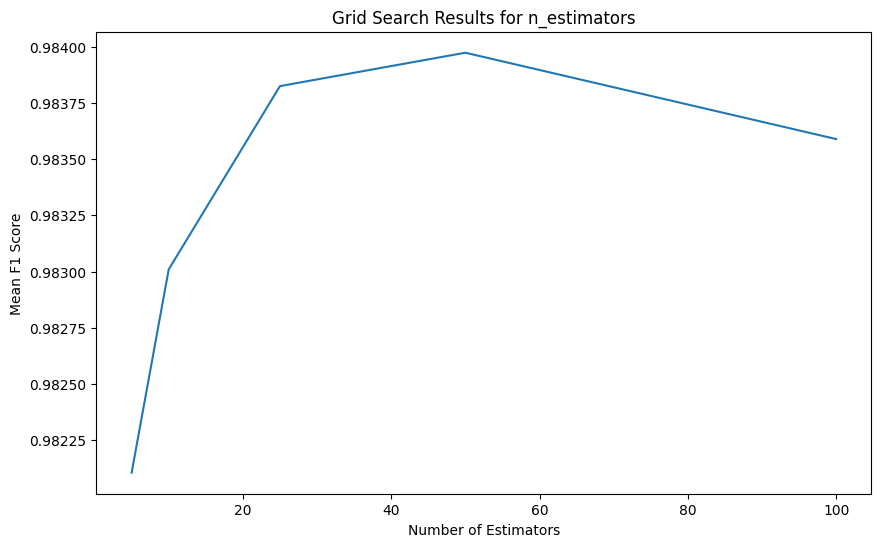

In [11]:
# visualizing the results of the grid search for n_estimators
results = pd.DataFrame(grid_search.cv_results_)
plt.figure(figsize=(10, 6))
sns.lineplot(x='param_n_estimators', y='mean_test_score', data=results)
plt.xlabel('Number of Estimators')
plt.ylabel('Mean F1 Score')
plt.title('Grid Search Results for n_estimators')
plt.show()

## 5. Tuning for learning rate 

In [12]:
# param grid for learning rate

param_grid_lr = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3]
}

grid_search_lr = GridSearchCV(estimator= lgbm_model, param_grid=param_grid_lr, cv=5, scoring='f1_weighted')
grid_search_lr.fit(X_train_encoded, y_train_encoded)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004031 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2713
[LightGBM] [Info] Number of data points in the train set: 403200, number of used features: 35
[LightGBM] [Info] Start training from score -3.403581
[LightGBM] [Info] Start training from score -0.531609
[LightGBM] [Info] Start training from score -0.969989
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003869 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2711
[LightGBM] [Info] Number of data points in the train set: 403200, number of used features: 35
[LightGBM] [Info] Start training from score -3.403581
[LightGBM] [Info] Start training from score -0.531609
[LightGBM] [Info] Star

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMClassifie...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold a

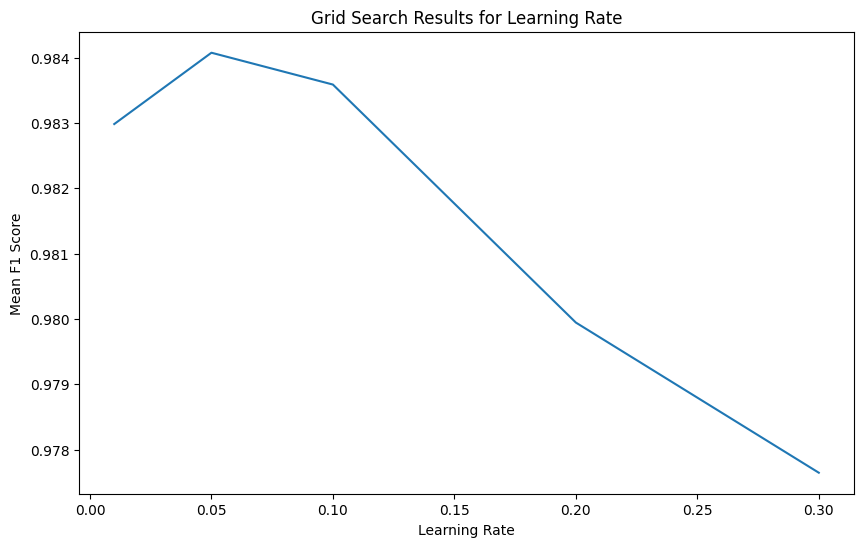

In [13]:
# Visualizing the results of the grid search for learning rate
results_lr = pd.DataFrame(grid_search_lr.cv_results_)
plt.figure(figsize=(10, 6))
sns.lineplot(x='param_learning_rate', y='mean_test_score', data=results_lr)
plt.xlabel('Learning Rate')
plt.ylabel('Mean F1 Score')
plt.title('Grid Search Results for Learning Rate')
plt.show()

## 6. Tuning for num leaves   

In [ ]:
# param grid for num leaves

param_grid_leaves = {
    'num_leaves': [15, 31, 63, 127, 255, 511]
}

grid_search_leaves = GridSearchCV(estimator= lgbm_model, param_grid=param_grid_leaves, cv=5, scoring='f1_weighted')
grid_search_leaves.fit(X_train_encoded, y_train_encoded)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004758 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2713
[LightGBM] [Info] Number of data points in the train set: 403200, number of used features: 35
[LightGBM] [Info] Start training from score -3.403581
[LightGBM] [Info] Start training from score -0.531609
[LightGBM] [Info] Start training from score -0.969989
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005314 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2711
[LightGBM] [Info] Number of data points in the train set: 403200, number of used features: 35
[LightGBM] [Info] Start training from score -3.403581
[LightGBM] [Info] Start training from score -0.531609
[LightGBM] [Info] Star

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMClassifie...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'num_leaves': [15, 31, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and cand

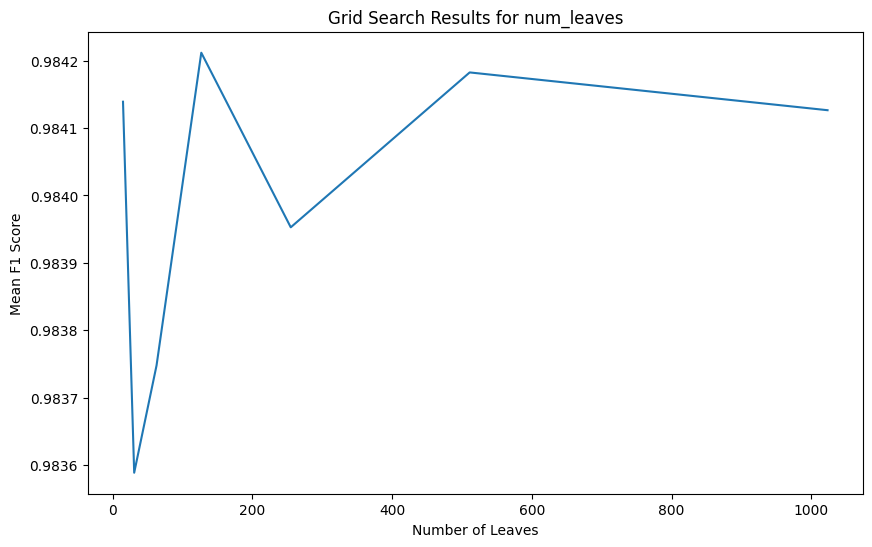

In [21]:
# visualizintg the results of the grid search for num leaves
results_leaves = pd.DataFrame(grid_search_leaves.cv_results_)
plt.figure(figsize=(10, 6))
sns.lineplot(x='param_num_leaves', y='mean_test_score', data=results_leaves)
plt.xlabel('Number of Leaves')
plt.ylabel('Mean F1 Score')
plt.title('Grid Search Results for num_leaves')
plt.show()

## 7. Combining all Tuned Features together 

In [22]:
# using all of the tuned features together to build a final model
final_model = LGBMClassifier(
    n_estimators=grid_search.best_params_['n_estimators'],
    learning_rate=grid_search_lr.best_params_['learning_rate'],
    num_leaves=grid_search_leaves.best_params_['num_leaves'],
    random_state=42
)

final_model.fit(X_train_encoded, y_train_encoded)
y_val_final_pred = final_model.predict(x_val_encoded)
print(classification_report(y_val_encoded, y_val_final_pred, target_names=le.classes_))
print("Final F1 Score:", f1_score(y_val_encoded, y_val_final_pred, average='weighted'))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006065 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2713
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 35
[LightGBM] [Info] Start training from score -3.403581
[LightGBM] [Info] Start training from score -0.531609
[LightGBM] [Info] Start training from score -0.969989
              precision    recall  f1-score   support

        High       0.96      0.90      0.93      4249
         Low       0.99      0.99      0.99     73737
      Medium       0.98      0.97      0.98     48014

    accuracy                           0.98    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.98      0.98      0.98    126000

Final F1 Score: 0.983565581920197


In [24]:
# displauing the difference in performance between the initial model and the final model
initial_f1 = f1_score(y_val_encoded, y_val_pred, average='weighted')
final_f1 = f1_score(y_val_encoded, y_val_final_pred, average='weighted')
print(f"Initial F1 Score: {initial_f1:.4f}")
print(f"Final F1 Score: {final_f1:.4f}")
print(f"Improvement in F1 Score: {final_f1 - initial_f1:.4f}")

Initial F1 Score: 0.9833
Final F1 Score: 0.9836
Improvement in F1 Score: 0.0003


## 8. Submission Output

In [25]:
test_data = pd.read_csv("test.csv")
test_data_no_id = test_data.drop('id', axis=1)
test_data_encoded = pd.get_dummies(test_data_no_id, drop_first=True)
test_data_encoded = test_data_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

In [26]:
test_predictions = final_model.predict(test_data_encoded)
submission = pd.DataFrame({
    'id': test_data['id'],
    'Irrigation_Need': le.inverse_transform(test_predictions)
})
submission.head(20)

,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low
5,630005,Medium
6,630006,Low
7,630007,Medium
8,630008,High
9,630009,Low


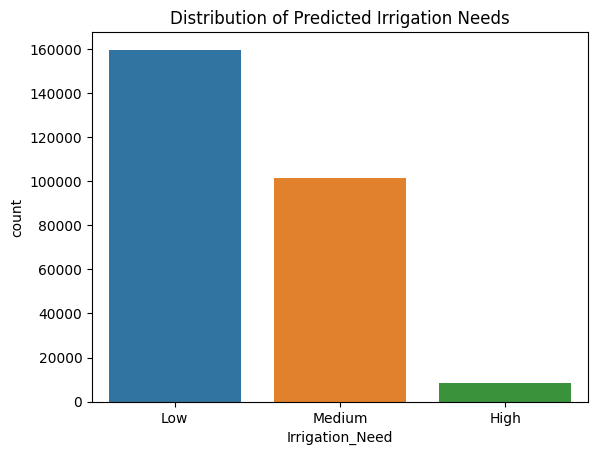

In [27]:
# visualizing the results of our final model on the test data 

sns.countplot(x=submission['Irrigation_Need'], hue=submission['Irrigation_Need'])
plt.title('Distribution of Predicted Irrigation Needs')
plt.show()

In [28]:
# creating submission file

submission.to_csv('LightGBM_Submission.csv', index=False)